In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

## state_schema

In [2]:
class AgentState(TypedDict):
    num_1: int
    num_2: int
    operation: str
    final_num: int

## Nodes

In [3]:
def adder(state: AgentState) -> AgentState:
    """This node adds 2 numbers"""

    state['final_num'] = state['num_1'] + state['num_2']
    
    return state

def subtractor(state: AgentState) -> AgentState:
    """This node subtract 2 numbers"""
    
    state['final_num'] = state['num_1'] - state['num_2']
    
    return state

def decide_next_node(state: AgentState):
    """This node will select the next node of the graph"""

    if state['operation'] == '+':

        return "addition_operation"
    
    elif state['operation'] == '-':

        return "subtraction_operation"
    

## Graph

In [4]:
graph = StateGraph(AgentState)


graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router", lambda state:state)


graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,

    {
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }
)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

app = graph.compile()

## Draw graph

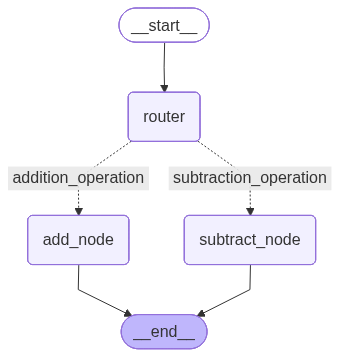

In [5]:
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
response = app.invoke(AgentState(num_1=4, num_2=2, operation='+'))

In [7]:
response['final_num']

6

# Exercise

# state_schema

In [8]:
class AgentState(TypedDict):
    num_1: int
    num_2: int
    operation_1: str
    final_num_1: int
    num_3: int
    num_4: int
    operation_2: str
    final_num_2: int

## Create Nodes

In [9]:
def add_node(state: AgentState) -> AgentState:
    """Adds two numbers"""

    state['final_num_1'] = state['num_1'] + state['num_2']

    return state

def subtract_node(state: AgentState) -> AgentState:
    """Subtracts two numbers"""

    state['final_num_1'] = state['num_1'] - state['num_2']

    return state



def add_node_2(state: AgentState) -> AgentState:
    """Adds two numbers"""

    state['final_num_2'] = state['num_3'] + state['num_4']

    return state

def subtract_node_2(state: AgentState) -> AgentState:
    """Subtracts two numbers"""

    state['final_num_2'] = state['num_3'] - state['num_4']

    return state

### Create routers

In [10]:
def router(state: AgentState):
    """This node will select the next node in the graph"""

    if state['operation_1'] == '+':

        return "addition_operation"
    
    elif state['operation_1'] == '-':

        return "subtraction_operation"


def router_2(state: AgentState):
    """This node will select the next node in the graph"""

    if state['operation_2'] == '+':

        return "addition_operation_2"
    
    elif state['operation_2'] == '-':

        return "subtraction_operation_2"

## Create graph

In [11]:
graph = StateGraph(AgentState)


graph.add_node("add_node", add_node)
graph.add_node("subtract_node", subtract_node)
graph.add_node("router", lambda state:state)

graph.add_node("add_node_2", add_node_2)
graph.add_node("subtract_node_2", subtract_node_2)
graph.add_node("router_2", lambda state:state)


graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    router,

    {
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }
)

graph.add_edge("add_node", "router_2")
graph.add_edge("subtract_node", "router_2")

graph.add_conditional_edges(
    "router_2",
    router_2,

    {

        "addition_operation_2": "add_node_2",
        "subtraction_node_2": "subtract_node_2"
    }
)

graph.add_edge("add_node_2", END)
graph.add_edge("subtract_node_2", END)



app = graph.compile()

## Draw Graph

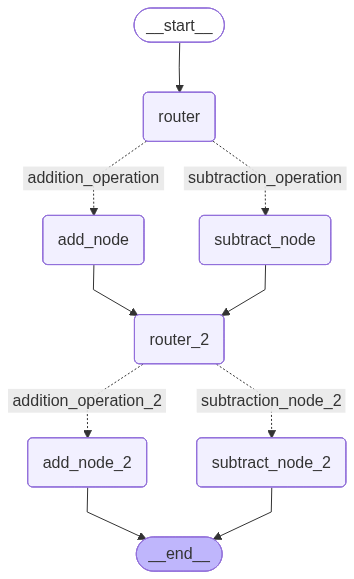

In [12]:
display(Image(app.get_graph().draw_mermaid_png()))

## Invoke

In [13]:
response = app.invoke(AgentState(num_1=1, num_2=2, num_3=3, num_4=4, operation_1='+', operation_2='+'))

In [14]:
response['final_num_1'], response['final_num_2']

(3, 7)